In [113]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
from src.models.utils import *
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import pearsonr



In [114]:
merged_df_path = os.path.join(project_root, "data", "processed", "joined_df.csv")
merged_df = pd.read_csv(merged_df_path, encoding='utf-8')

In [115]:
power_plants = merged_df[['name', 'code']].drop_duplicates()
power_plants = power_plants[power_plants['code'].str.startswith("G")]

In [116]:
corr_pearsons = []
for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    corr_pearson, _ = pearsonr(senstemps, gens)
    print(f"{name}, {code} : {corr_pearson}")
    corr_pearsons.append(corr_pearson)


پرند, G12 : -0.5265931846152585
پرند, G11 : -0.796442050183885
پرند, G14 : -0.9456191519824488
پرند, G16 : -0.9508421182148773
پرند, G15 : -0.925932866574103
پرند, G13 : -0.964460999283796
شهدای پیروز - بهبهان, G12 : -0.6350903737263448
شهدای پیروز - بهبهان, G11 : -0.8103202947419064
جنوب اصفهان - چهلستون, G14 : -0.971783408106794
جنوب اصفهان - چهلستون, G15 : -0.1602599688465528
جنوب اصفهان - چهلستون, G12 : -0.7771208128485111
جنوب اصفهان - چهلستون, G13 : -0.9552512871753324
جنوب اصفهان - چهلستون, G11 : -0.8651229786124891
سبلان, G13 : -0.8874184219438542
سبلان, G14 : -0.888010192860318
سبلان, G15 : -0.9010995184685502
جنوب اصفهان - چهلستون, G16 : -0.9789219924953909
سبلان, G12 : -0.9471129909392697
سبلان, G11 : -0.8768627150348156
سیکل ترکیبی ارومیه, G12 : -0.9112954938779164
سیکل ترکیبی ارومیه, G14 : -0.6666226307288264
سیکل ترکیبی ارومیه, G13 : -0.5990367560608467
سیکل ترکیبی ارومیه, G16 : -0.9323573079692002
سیکل ترکیبی ارومیه, G15 : -0.5170458059921242
سیکل ترکیبی ارومیه, G11 : -0

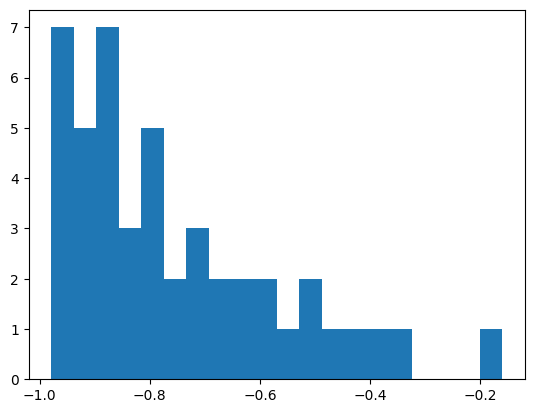

In [117]:
plt.hist(corr_pearsons, bins=20)
plt.show()

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import xgboost as xgb


In [119]:
test_errors = []
for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    X = senstemps.reshape(-1, 1)
    y = gens

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    # model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, seed=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_error = compute_relative_rmse(y_pred_train, y_train)
    test_error = compute_relative_rmse(y_pred_test, y_test)

    print(f"{name}, {code}, train error: {train_error:0.2f}, test error: {test_error:0.2f}")
    test_errors.append(test_error)


پرند, G12, train error: 6.08, test error: 6.24
پرند, G11, train error: 6.73, test error: 6.82
پرند, G14, train error: 1.75, test error: 1.78
پرند, G16, train error: 1.46, test error: 1.54
پرند, G15, train error: 1.66, test error: 1.69
پرند, G13, train error: 1.47, test error: 1.57
شهدای پیروز - بهبهان, G12, train error: 4.47, test error: 4.35
شهدای پیروز - بهبهان, G11, train error: 4.08, test error: 4.00
جنوب اصفهان - چهلستون, G14, train error: 0.84, test error: 0.52
جنوب اصفهان - چهلستون, G15, train error: 1.40, test error: 1.72
جنوب اصفهان - چهلستون, G12, train error: 2.15, test error: 1.83
جنوب اصفهان - چهلستون, G13, train error: 0.96, test error: 0.62
جنوب اصفهان - چهلستون, G11, train error: 2.56, test error: 2.64
سبلان, G13, train error: 1.66, test error: 1.79
سبلان, G14, train error: 1.74, test error: 1.69
سبلان, G15, train error: 1.59, test error: 1.54
جنوب اصفهان - چهلستون, G16, train error: 0.64, test error: 1.02
سبلان, G12, train error: 1.56, test error: 1.50
سبلان, G11, trai

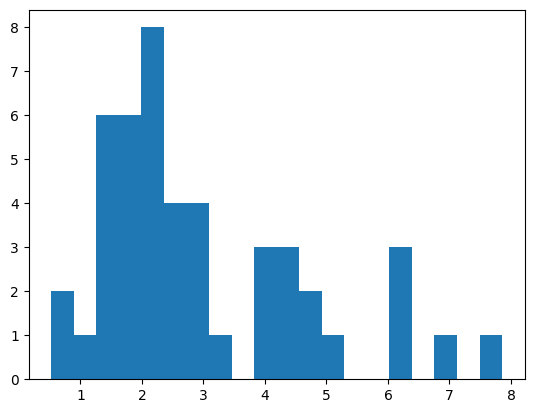

In [120]:
plt.hist(test_errors, bins=20)
plt.show()

In [121]:
from sklearn.cluster import KMeans


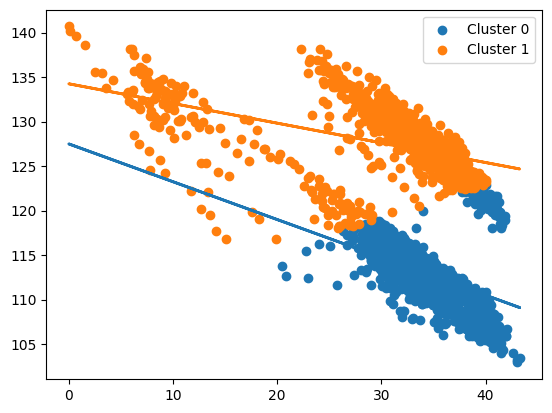

In [122]:
np.random.seed(42)

name = "پرند"
code = "G12"
filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
senstemps = filtered_df['sen_temperature'].values
gens = filtered_df['generation'].values
X = senstemps.reshape(-1, 1)
y = gens

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(np.c_[X, y])

for cluster in np.unique(labels):
    mask = labels == cluster
    reg = LinearRegression().fit(X[mask], y[mask])
    plt.scatter(X[mask], y[mask], label=f'Cluster {cluster}')
    plt.plot(X, reg.predict(X), linewidth=2)

plt.legend()
plt.show()

In [123]:
from sklearn.linear_model import RANSACRegressor

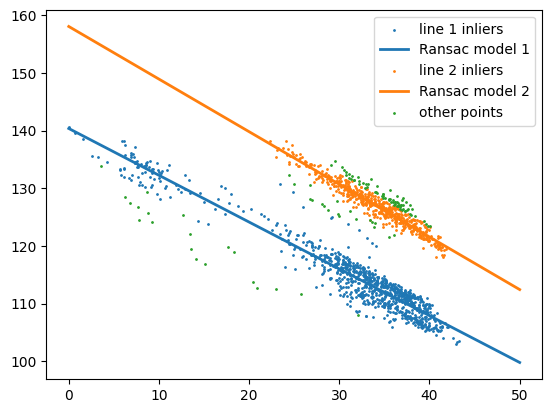

In [124]:
np.random.seed(42)

name = "پرند"
code = "G12"
filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
senstemps = filtered_df['sen_temperature'].values
gens = filtered_df['generation'].values
X = senstemps.reshape(-1, 1)
y = gens

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_filtered = X_train.copy()
y_filtered = y_train.copy()

lines = []
while True:
    ransac = RANSACRegressor(LinearRegression(), random_state=42)
    ransac.fit(X_filtered, y_filtered)

    inlier_mask = ransac.inlier_mask_
    lines.append((ransac, inlier_mask, X_filtered, y_filtered))

    X_filtered = X_filtered[~inlier_mask]
    y_filtered = y_filtered[~inlier_mask]
    if len(X_filtered) / len(X) < 0.3:
        break
    
y_preds = []
for i, (ransac, inlier_mask, X_part, y_part) in enumerate(lines):
    line_X = np.linspace(0, 50, 1000).reshape(-1, 1)
    line_y = ransac.predict(line_X)
    plt.scatter(X_part[inlier_mask], y_part[inlier_mask], label=f"line {i + 1} inliers", s=1)
    plt.plot(line_X, line_y, linewidth=2, label=f"Ransac model {i + 1}")
    y_preds.append(ransac.predict(X_test))

plt.scatter(X_filtered, y_filtered, label="other points", s=1)
plt.legend()
plt.show()



In [125]:
y_diffs = np.array([np.abs(y_pred - y_test) for y_pred in y_preds])
min_diff = np.min(y_diffs, axis=0)


In [126]:
rmse = np.sqrt(np.mean(min_diff**2))
relative_error = rmse / np.mean(y_test) * 100
print(f"{relative_error: 0.2f}")

 1.55


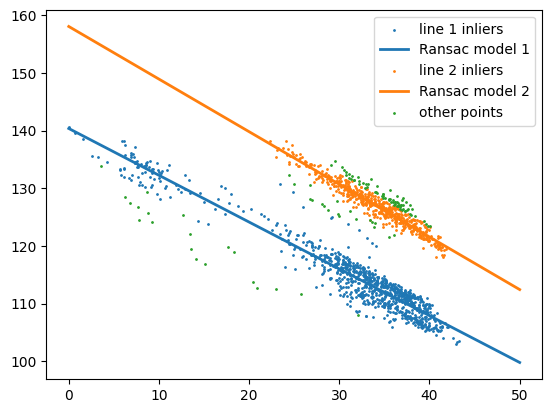

 1.55


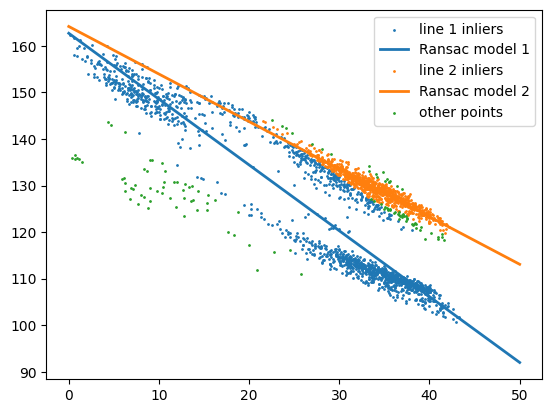

 3.61


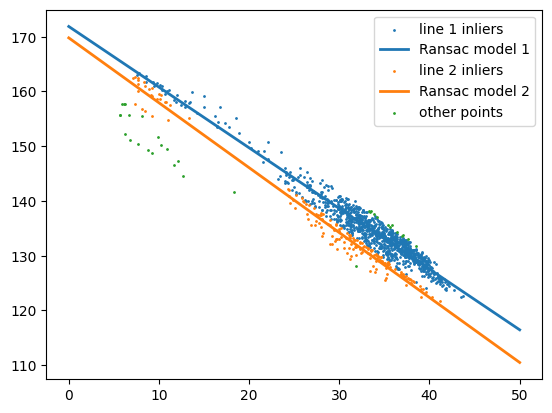

 1.19


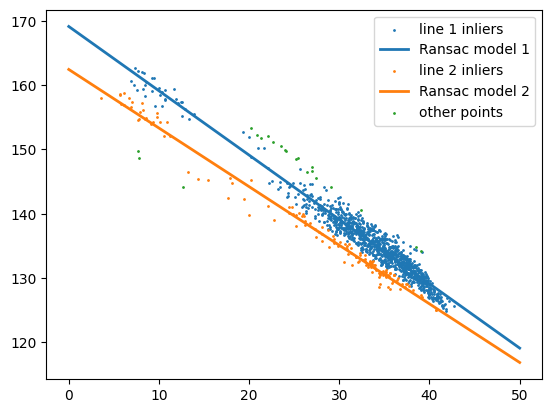

 1.03


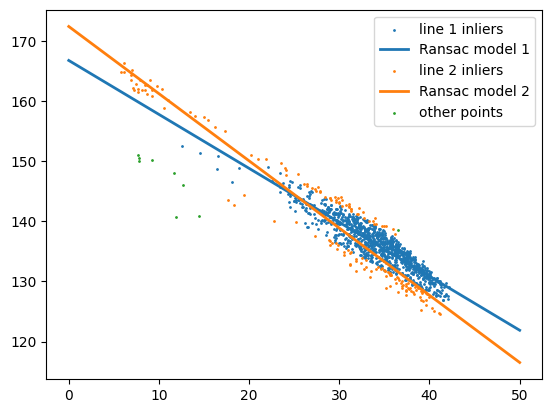

 1.40


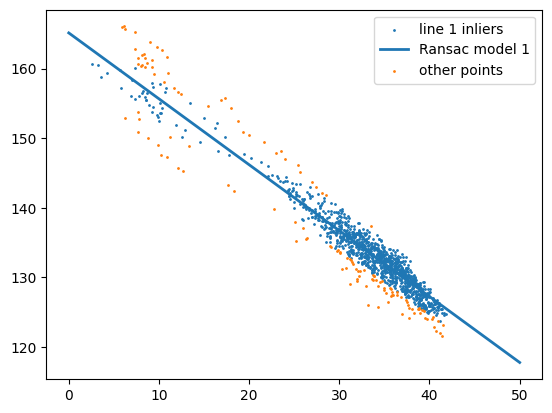

 1.54


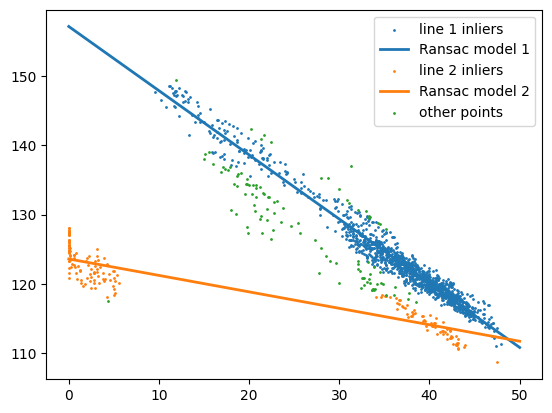

 1.66


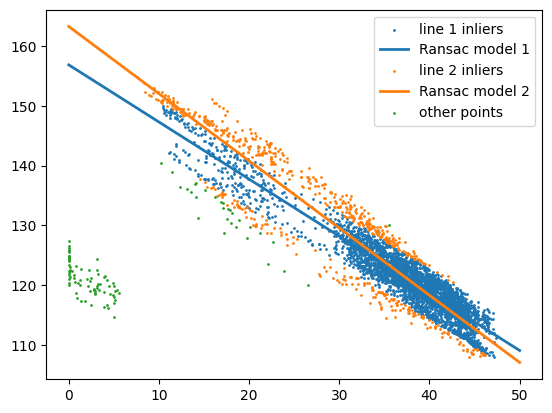

 4.02


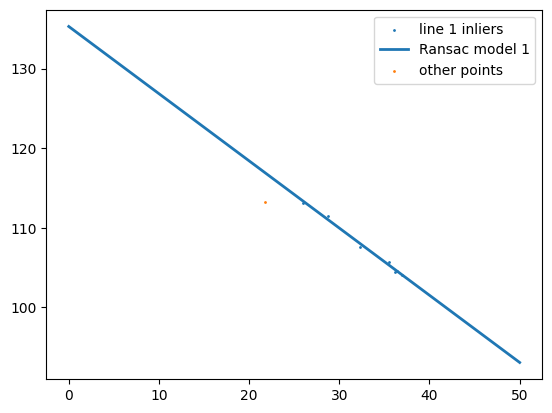

 0.10


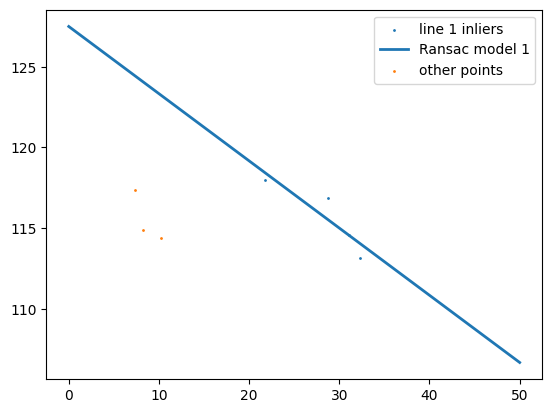

 4.70


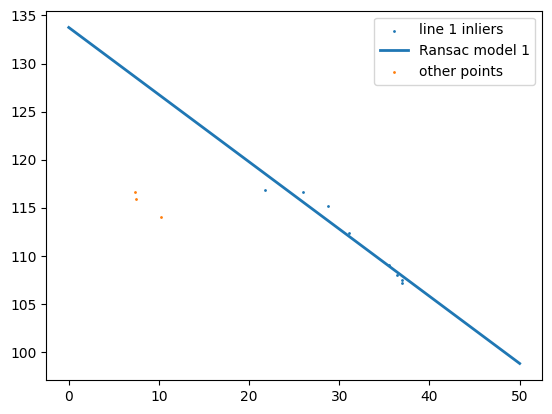

 7.12


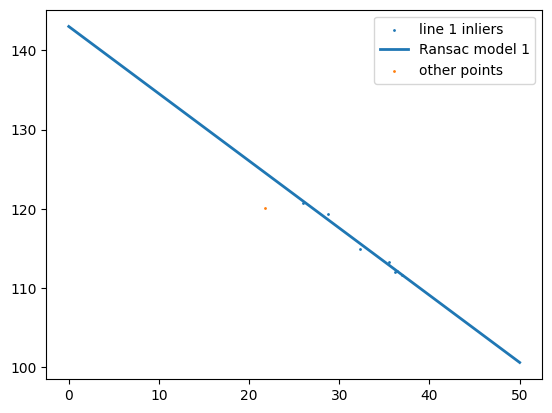

 0.16


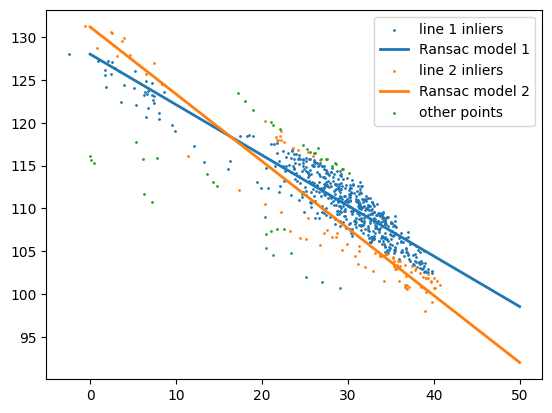

 2.31


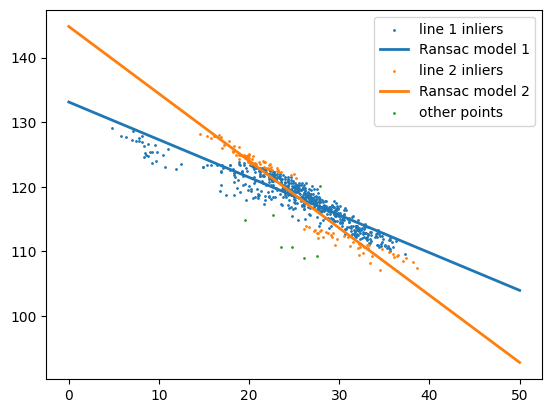

 1.38


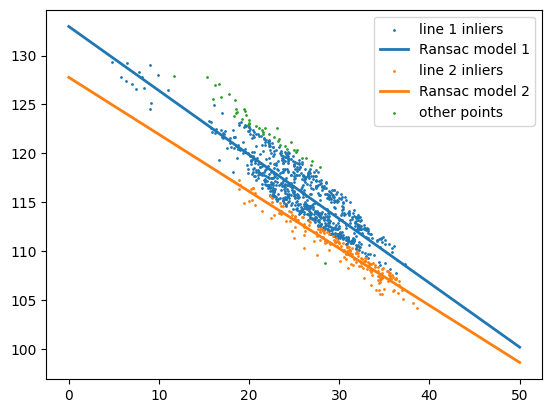

 1.30


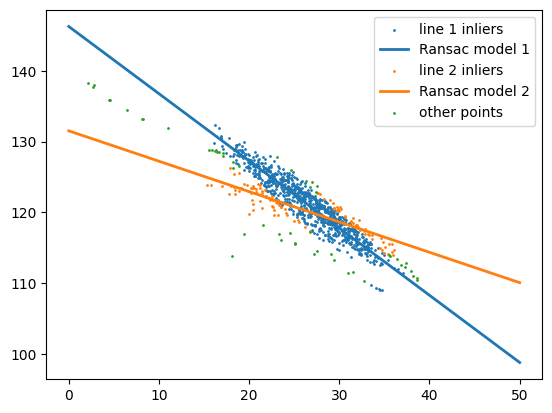

 1.17


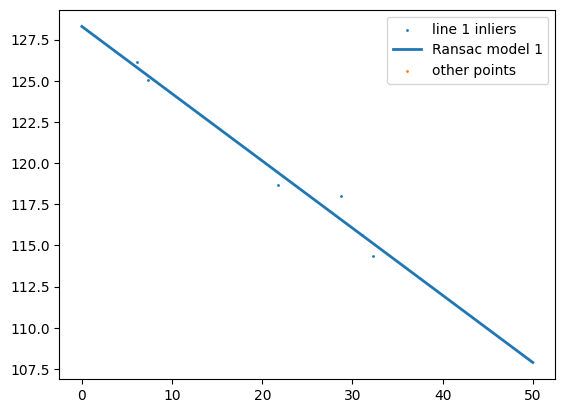

 1.02


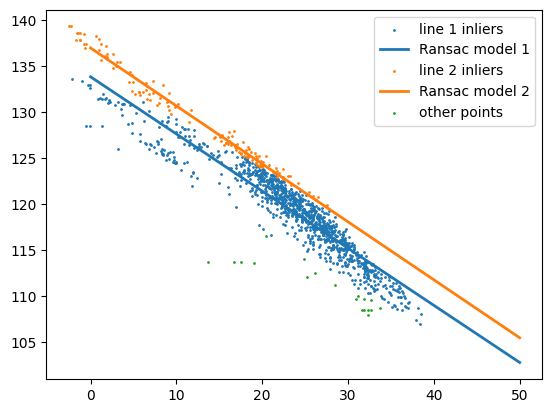

 1.20


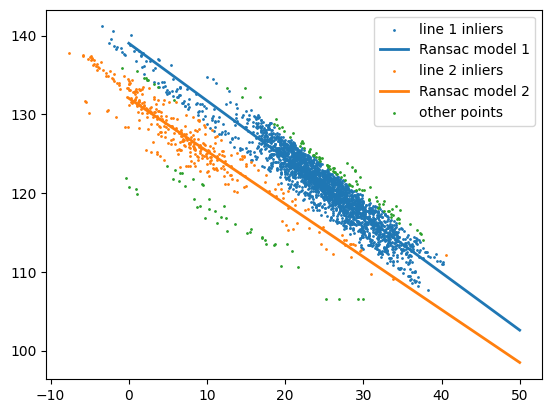

 1.39


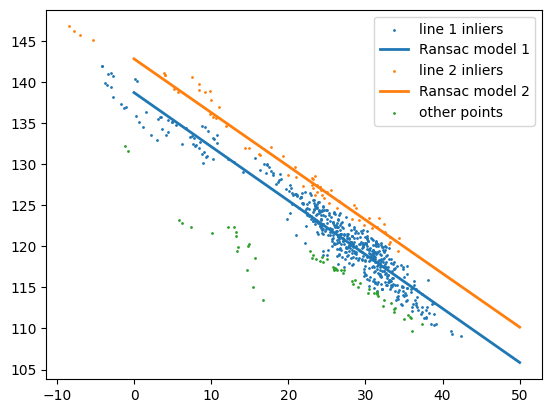

 1.66


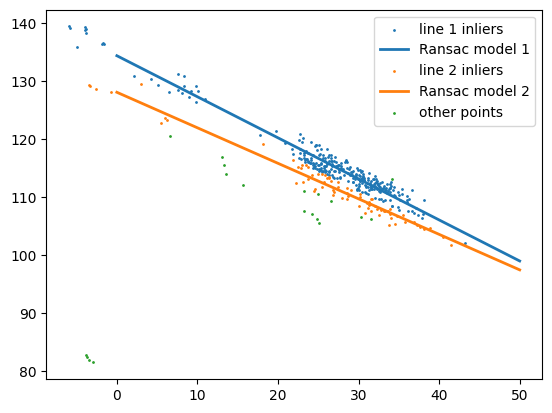

 1.02


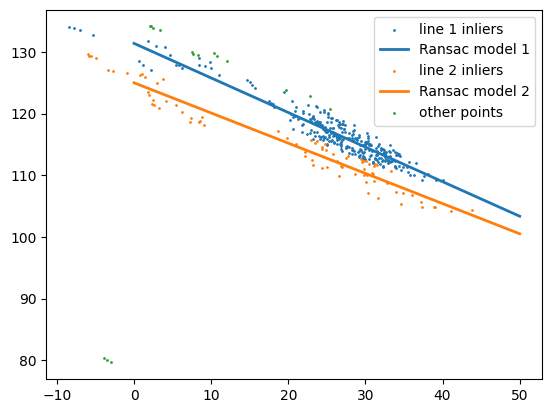

 4.35


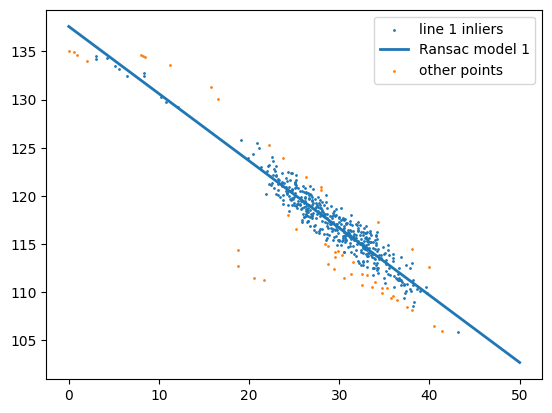

 1.32


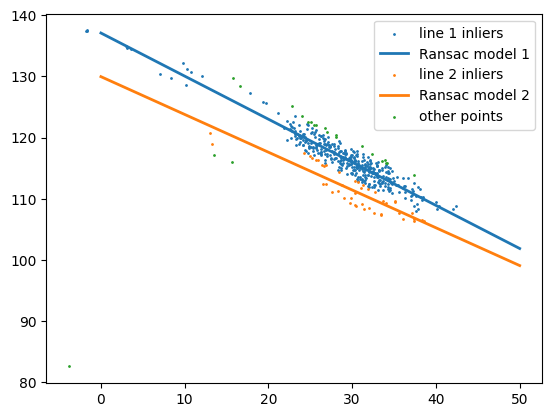

 7.27


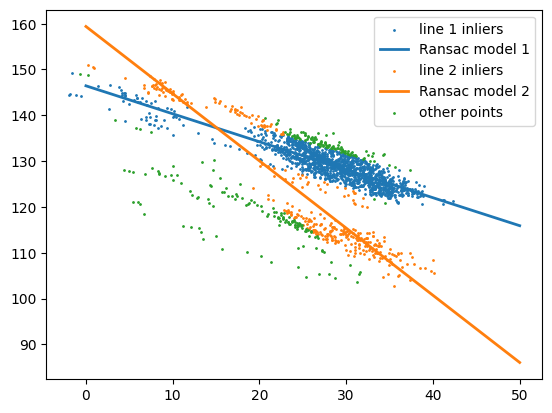

 2.69


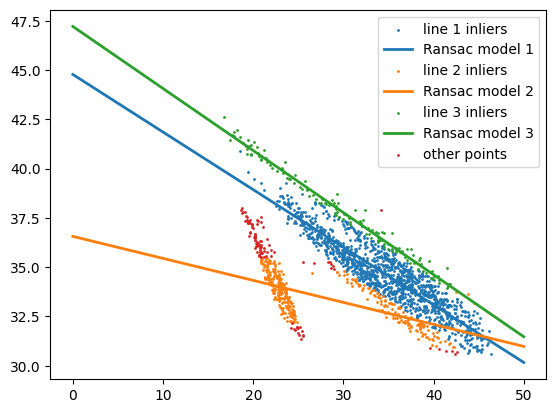

 2.08


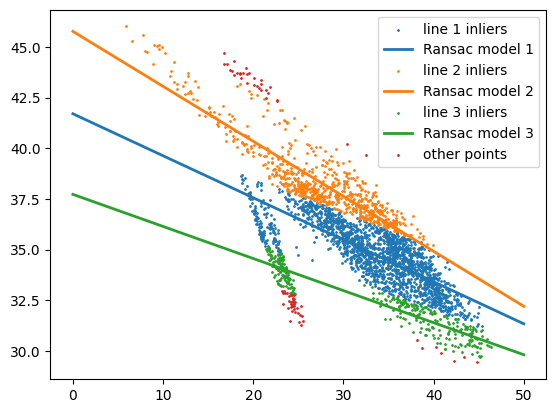

 2.12


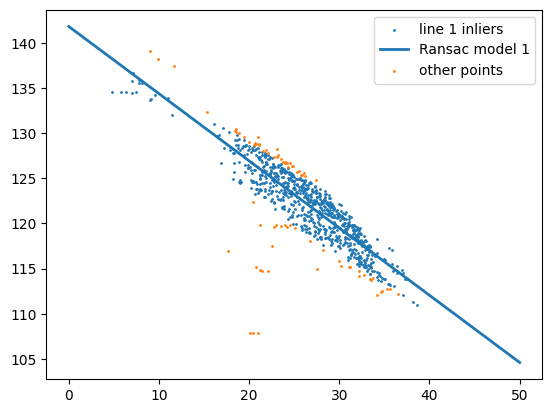

 2.11


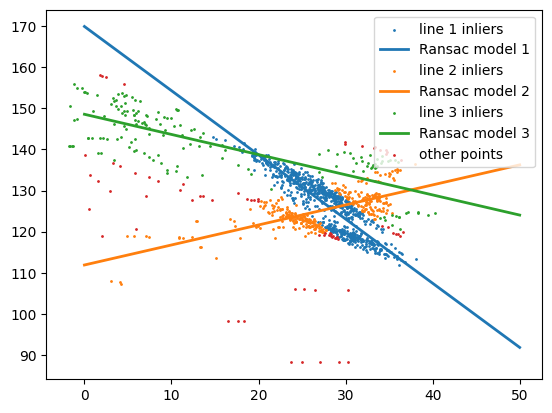

 3.88


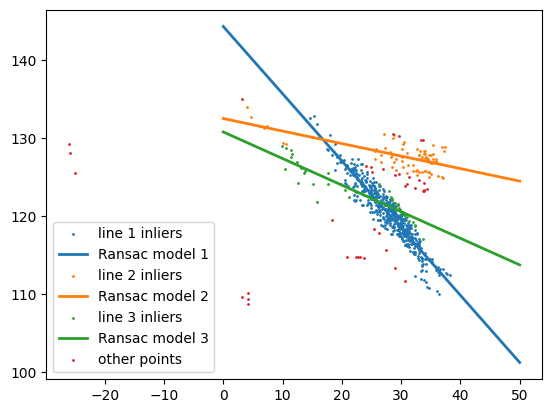

 1.49


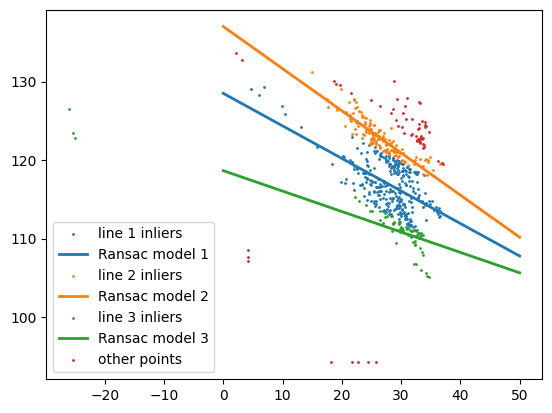

 1.88


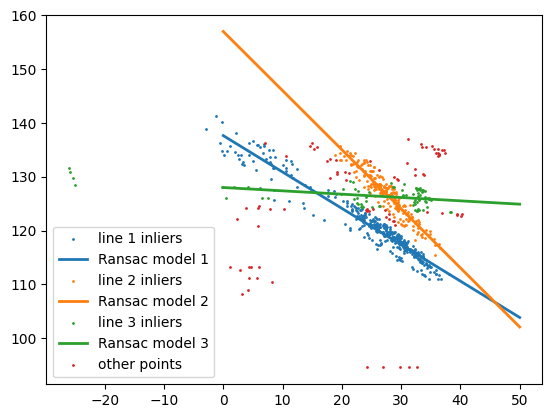

 2.47


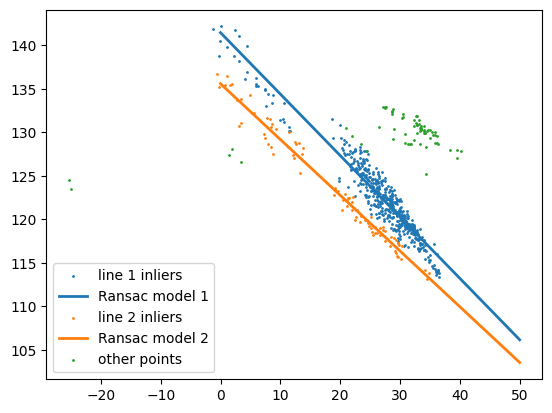

 6.79


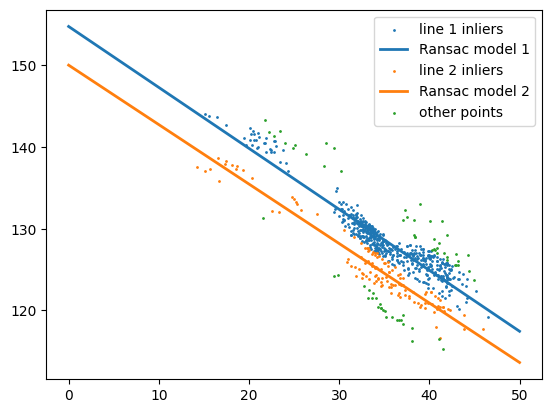

 1.54


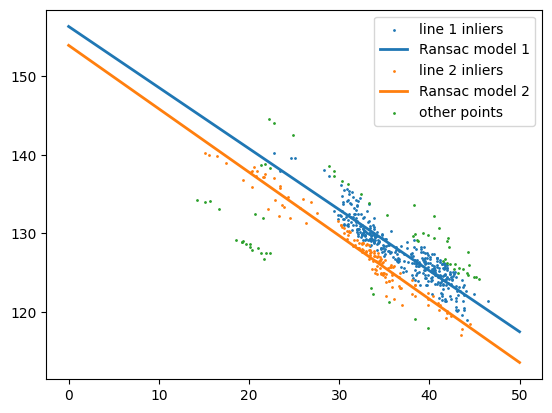

 1.62


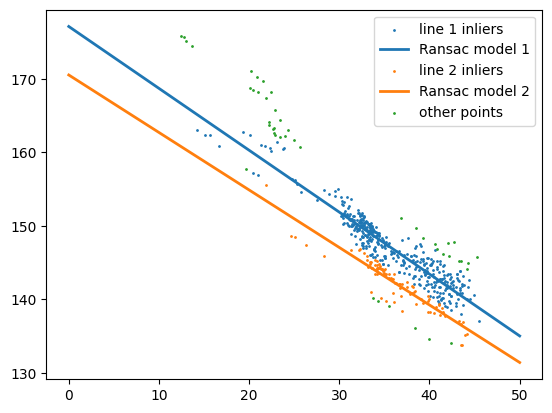

 0.95


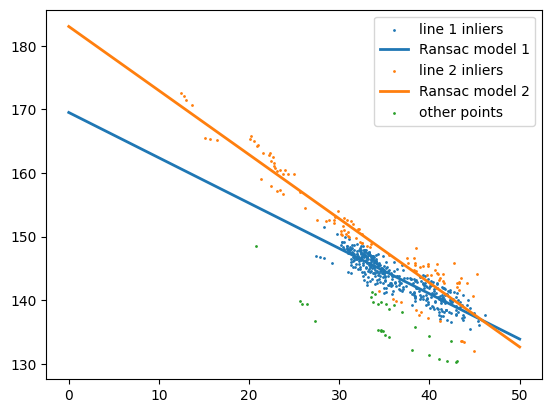

 1.48


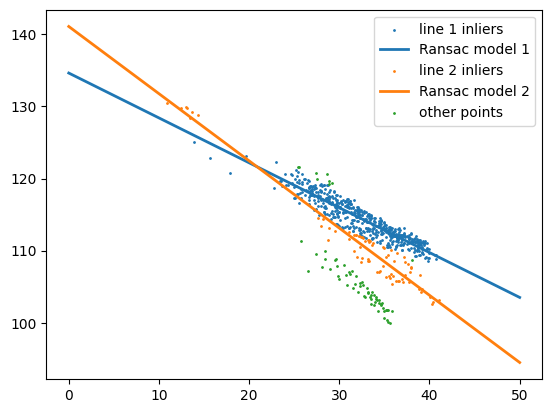

 2.00


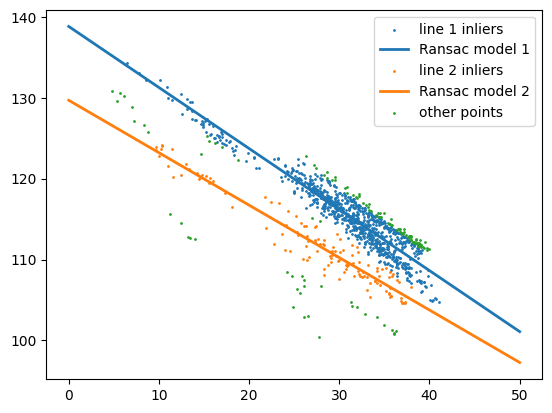

 1.84


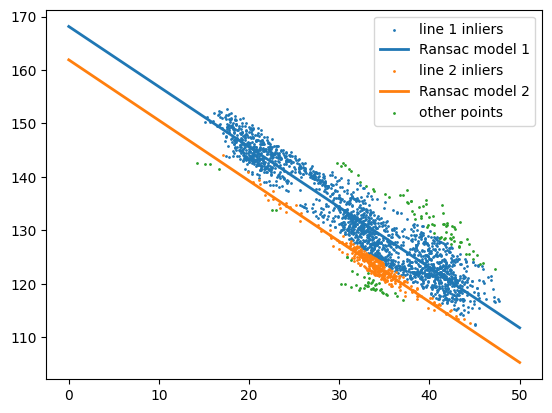

 2.09


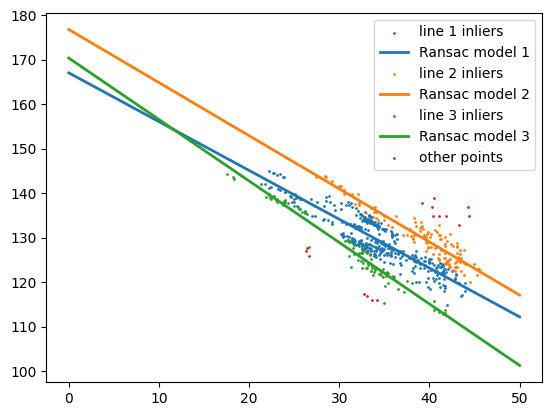

 1.69


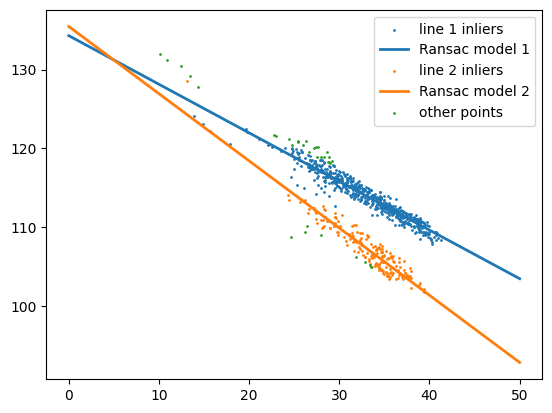

 0.75


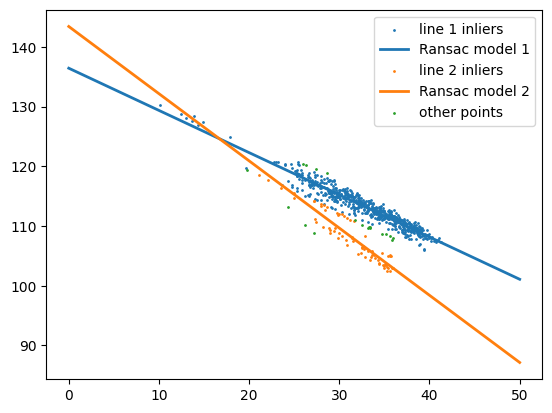

 1.01


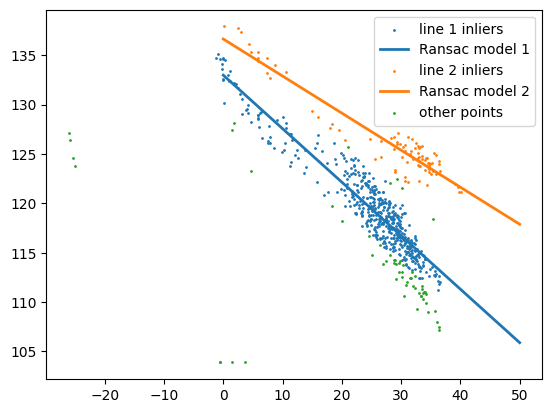

 1.57


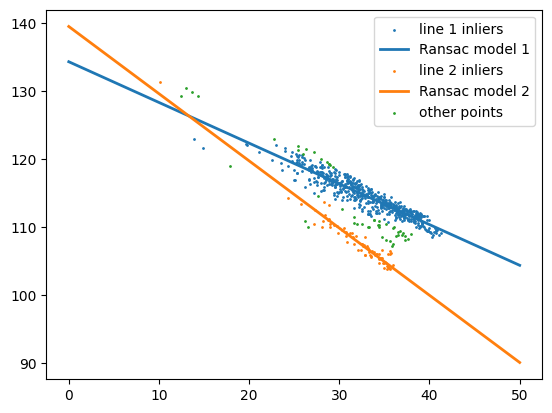

 1.12


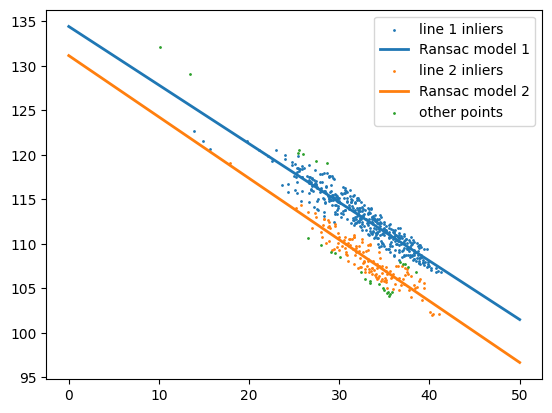

 1.04


In [127]:
def my_func(name, code):
    global filtered_df
    np.random.seed(42)
    filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    X = senstemps.reshape(-1, 1)
    y = gens
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_filtered = X_train.copy()
    y_filtered = y_train.copy()
    lines = []
    while True:
        ransac = RANSACRegressor(LinearRegression(), random_state=42)
        ransac.fit(X_filtered, y_filtered)

        inlier_mask = ransac.inlier_mask_
        lines.append((ransac, inlier_mask, X_filtered, y_filtered))

        X_filtered = X_filtered[~inlier_mask]
        y_filtered = y_filtered[~inlier_mask]
        if len(X_filtered) / len(X) < 0.1 or len(X_filtered) < 10:
            break
    y_preds = []
    for i, (ransac, inlier_mask, X_part, y_part) in enumerate(lines):
        line_X = np.linspace(0, 50, 1000).reshape(-1, 1)
        line_y = ransac.predict(line_X)
        plt.scatter(X_part[inlier_mask], y_part[inlier_mask], label=f"line {i + 1} inliers", s=1)
        plt.plot(line_X, line_y, linewidth=2, label=f"Ransac model {i + 1}")
        y_preds.append(ransac.predict(X_test))
    plt.scatter(X_filtered, y_filtered, label="other points", s=1)
    plt.legend()
    plt.show()
    y_diffs = np.array([np.abs(y_pred - y_test) for y_pred in y_preds])
    min_diff = np.min(y_diffs, axis=0)
    rmse = np.sqrt(np.mean(min_diff ** 2))
    relative_error = rmse / np.mean(y_test) * 100
    print(f"{relative_error: 0.2f}")


for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    my_func(name, code)